# 03 — Modélisation & Prévision de la Demande (RIE BNP Paribas)

Ce notebook entraîne et compare plusieurs modèles de prévision pour estimer le nombre
de repas servis (`employees_count`) chaque jour ouvrable de 2024.

**Pipeline :**
1. Chargement des features pré-calculées (`data/processed/`)
2. Préparation des matrices X / y + imputation
3. Baseline — Moyenne glissante (7 jours)
4. LightGBM — Cross-validation temporelle
5. CatBoost — Cross-validation temporelle
6. XGBoost — Cross-validation temporelle
7. Comparaison des modèles → sélection du meilleur
8. Tuning Optuna du meilleur modèle
9. Ensemble pondéré (3 modèles)
10. Importance des features
11. Prédictions finales & génération de la soumission

> **Cible modélisée :** `ratio = employees_count / office_present`
> Prédiction finale = `round(ratio_prédit × office_present_test)`

## 0. Setup & Chargement

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR   = REPO_ROOT / 'data' / 'processed'

# ── Load processed features ───────────────────────────────────────────────
train = pd.read_parquet(OUT_DIR / 'train_features.parquet')
test  = pd.read_parquet(OUT_DIR / 'test_features.parquet')

with open(OUT_DIR / 'feature_columns.json', encoding='utf-8') as f:
    FEATURE_COLS = json.load(f)

print(f"Train : {train.shape} | {train.Date.min().date()} -> {train.Date.max().date()}")
print(f"Test  : {test.shape}  | {test.Date.min().date()} -> {test.Date.max().date()}")
print(f"Features : {len(FEATURE_COLS)}")

Train : (399, 66) | 2022-05-04 -> 2023-12-31
Test  : (229, 64)  | 2024-01-02 -> 2024-12-31
Features : 63


## 1. Préparation des Matrices X / y

### Stratégie d'imputation
- `type precipitation` & `conditions` : NaN = absence de pluie/conditions spéciales → encodé `"none"`.
- Lags initiaux (7–28 premières lignes) : médiane du train (fit sur train, appliquée partout).
- `roll_std_7` : médiane du train (std NaN quand fenêtre < 2 valeurs).

### Encodage des catégorielles
Les colonnes `conditions` et `type precipitation` sont encodées en entiers.
LightGBM et CatBoost les reconnaissent comme catégorielles nativement.

In [2]:
CAT_COLS = ['conditions', 'type precipitation']
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]

def prepare_matrices(train_df, test_df, feature_cols):
    """Impute, encode et retourne X_train, y_ratio, X_test, office_test."""
    cat_cols = [c for c in CAT_COLS if c in feature_cols]
    num_cols = [c for c in feature_cols if c not in cat_cols]

    X_tr = train_df[feature_cols].copy()
    X_te = test_df[[c for c in feature_cols if c in test_df.columns]].copy()

    # ── Catégorielles : fillna + encode ──────────────────────────────────
    for col in cat_cols:
        X_tr[col] = X_tr[col].fillna('none').astype(str)
        X_te[col] = X_te[col].fillna('none').astype(str) if col in X_te.columns else 'none'

        all_cats = sorted(set(X_tr[col].unique()) | set(X_te[col].unique()))
        cat_map  = {v: i for i, v in enumerate(all_cats)}
        X_tr[col] = X_tr[col].map(cat_map).astype(int)
        X_te[col] = X_te[col].map(cat_map).fillna(0).astype(int)

    # ── Numériques : impute avec médiane du train ─────────────────────────
    medians = X_tr[num_cols].median()
    X_tr[num_cols] = X_tr[num_cols].fillna(medians)
    X_te[num_cols] = X_te[num_cols].fillna(medians)

    # ── Colonnes manquantes dans test (office_per_dept éventuellement) ──
    for col in feature_cols:
        if col not in X_te.columns:
            X_te[col] = medians.get(col, 0)
    X_te = X_te[feature_cols]

    y_ratio = (train_df['employees_count'] / train_df['office_present']).astype(float)
    office_test = test_df['office_present'].values

    return X_tr, y_ratio, X_te, office_test, cat_cols

X_train, y_ratio, X_test, office_test, cat_cols_idx = prepare_matrices(train, test, FEATURE_COLS)

print(f"X_train : {X_train.shape} | NaN restants : {X_train.isna().sum().sum()}")
print(f"X_test  : {X_test.shape}  | NaN restants : {X_test.isna().sum().sum()}")
print(f"y_ratio : mean={y_ratio.mean():.3f}, std={y_ratio.std():.3f}, "
      f"min={y_ratio.min():.3f}, max={y_ratio.max():.3f}")

X_train : (399, 63) | NaN restants : 0
X_test  : (229, 63)  | NaN restants : 0
y_ratio : mean=0.553, std=0.061, min=0.309, max=0.739


## 2. Métriques & Utilitaires de Validation

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

def asymmetric_cost(y_true, y_pred):
    """Coût asymétrique : sous-estimation pénalisée 2x. Normalisé par la somme des vraies valeurs."""    
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    diff   = y_pred - y_true
    cost   = np.sum(np.where(diff < 0, -2 * diff, diff)) / np.sum(y_true)
    return float(cost)

def ratio_to_count(ratio_pred, office_present):
    """Convertit les prédictions de ratio en nombre de repas entier."""    
    return np.clip(np.rint(ratio_pred * office_present), 0, None).astype(int)

def evaluate(y_true_ratio, y_pred_ratio, office):
    """Évalue les prédictions en ratio ET en volume absolu."""    
    y_true_count = np.round(y_true_ratio.values * office).astype(int)
    y_pred_count = ratio_to_count(y_pred_ratio, office)
    return {
        'MAE (repas)' : round(mean_absolute_error(y_true_count, y_pred_count), 2),
        'RMSE (repas)': round(np.sqrt(mean_squared_error(y_true_count, y_pred_count)), 2),
        'Asym. Cost'  : round(asymmetric_cost(y_true_count, y_pred_count), 5),
        'MAE (ratio)' : round(mean_absolute_error(y_true_ratio, y_pred_ratio), 5),
    }

def cross_validate_model(model_fn, X, y_ratio, office, n_splits=5):
    """TimeSeriesSplit CV — retourne scores par fold + scores moyens."""    
    tscv   = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
        model = model_fn()
        model.fit(X.iloc[tr_idx], y_ratio.iloc[tr_idx])
        preds  = model.predict(X.iloc[val_idx])
        office_val = office[val_idx]
        s = evaluate(y_ratio.iloc[val_idx], preds, office_val)
        s['Fold'] = fold + 1
        scores.append(s)
    df = pd.DataFrame(scores).set_index('Fold')
    print(df.to_string())
    print()
    print("Moyenne :")
    print(df.mean().round(4).to_string())
    return df

office_arr = train['office_present'].values
N_CV = 5
print("Utilitaires de validation prets.")

Utilitaires de validation prets.


## 3. Baseline — Moyenne glissante 7 jours du ratio

Référence la plus simple : prédit le ratio moyen des 7 jours ouvrés précédents.
Tous les modèles ML doivent **battre** cette baseline.

In [6]:
train_sorted = train.sort_values('Date').reset_index(drop=True).copy()
train_sorted['ratio'] = y_ratio.values

# Baseline : rolling mean du ratio (shift 1 pour éviter la fuite)
train_sorted['baseline_pred_ratio'] = (
    train_sorted['ratio'].shift(1).rolling(7, min_periods=1).mean()
)
train_sorted['baseline_pred_ratio'] = train_sorted['baseline_pred_ratio'].fillna(y_ratio.mean())

# Evaluer sur les 80 derniers jours (simulation validation)
val_mask = train_sorted.index >= len(train_sorted) - 80
y_val_ratio   = train_sorted.loc[val_mask, 'ratio']
y_bl_ratio    = train_sorted.loc[val_mask, 'baseline_pred_ratio']
office_val_bl = train_sorted.loc[val_mask, 'office_present'].values

baseline_scores = evaluate(y_val_ratio, y_bl_ratio, office_val_bl)
print("=== Baseline (Rolling Mean 7j — 80 derniers jours) ===")
for k, v in baseline_scores.items():
    print(f"  {k:20s}: {v}")

=== Baseline (Rolling Mean 7j — 80 derniers jours) ===
  MAE (repas)         : 17.85
  RMSE (repas)        : 23.95
  Asym. Cost          : 0.08077
  MAE (ratio)         : 0.03147


## 4. LightGBM

Paramètres de départ conservateurs. Objectif quantile `alpha=0.73` pour tenir compte
du coût asymétrique (sous-estimation pénalisée 2×).

In [7]:
try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM non disponible.")

LGBM_PARAMS = dict(
    objective       = 'quantile',
    alpha           = 0.73,
    n_estimators    = 500,
    learning_rate   = 0.04,
    num_leaves      = 31,
    min_child_samples = 12,
    subsample       = 0.85,
    subsample_freq  = 1,
    colsample_bytree= 0.85,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    verbosity       = -1,
)

if HAS_LGBM:
    # Indices des colonnes catégorielles
    cat_feature_indices = [list(X_train.columns).index(c)
                           for c in cat_cols_idx if c in X_train.columns]

    def make_lgbm():
        return LGBMRegressor(**LGBM_PARAMS)

    print("=== LightGBM — TimeSeriesSplit CV (5 folds) ===")
    lgbm_cv = cross_validate_model(make_lgbm, X_train, y_ratio, office_arr, N_CV)

=== LightGBM — TimeSeriesSplit CV (5 folds) ===
      MAE (repas)  RMSE (repas)  Asym. Cost  MAE (ratio)
Fold                                                    
1           21.11         25.94     0.11991      0.04277
2           34.14         41.01     0.12592      0.06134
3           18.53         23.80     0.08852      0.03236
4           18.48         25.33     0.10861      0.03640
5           18.03         23.49     0.07781      0.03142

Moyenne :
MAE (repas)     22.0580
RMSE (repas)    27.9140
Asym. Cost       0.1042
MAE (ratio)      0.0409


## 5. CatBoost

CatBoost gère les catégorielles nativement (on lui passe les indices directement)
et converge souvent mieux sur les petits datasets (<1000 lignes).

In [8]:
try:
    from catboost import CatBoostRegressor
    HAS_CB = True
except ImportError:
    HAS_CB = False
    print("CatBoost non disponible.")

CB_PARAMS = dict(
    loss_function   = 'Quantile:alpha=0.73',
    iterations      = 500,
    learning_rate   = 0.05,
    depth           = 6,
    l2_leaf_reg     = 3,
    random_seed     = 42,
    verbose         = 0,
)

if HAS_CB:
    cat_feature_names = [c for c in cat_cols_idx if c in X_train.columns]

    def make_catboost():
        return CatBoostRegressor(**CB_PARAMS, cat_features=cat_feature_names)

    print("=== CatBoost — TimeSeriesSplit CV (5 folds) ===")
    cb_cv = cross_validate_model(make_catboost, X_train, y_ratio, office_arr, N_CV)

=== CatBoost — TimeSeriesSplit CV (5 folds) ===


KeyboardInterrupt: 

## 6. XGBoost

XGBoost ne gère pas les catégorielles nativement — elles sont déjà encodées en entiers
à l'étape 1. On utilise `reg:squarederror` pour la stabilité.

In [9]:
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost non disponible.")

XGB_PARAMS = dict(
    objective       = 'reg:squarederror',
    n_estimators    = 500,
    learning_rate   = 0.04,
    max_depth       = 6,
    subsample       = 0.85,
    colsample_bytree= 0.85,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    verbosity       = 0,
)

if HAS_XGB:
    def make_xgb():
        return XGBRegressor(**XGB_PARAMS)

    print("=== XGBoost — TimeSeriesSplit CV (5 folds) ===")
    xgb_cv = cross_validate_model(make_xgb, X_train, y_ratio, office_arr, N_CV)

=== XGBoost — TimeSeriesSplit CV (5 folds) ===
      MAE (repas)  RMSE (repas)  Asym. Cost  MAE (ratio)
Fold                                                    
1           16.55         21.11     0.09372      0.03498
2           32.82         39.61     0.12241      0.05896
3           19.03         23.88     0.10094      0.03323
4           24.79         29.92     0.15440      0.04866
5           18.50         24.32     0.09209      0.03236

Moyenne :
MAE (repas)     22.3380
RMSE (repas)    27.7680
Asym. Cost       0.1127
MAE (ratio)      0.0416


## 7. Comparaison des Modèles

In [11]:
results = {'Baseline (Rolling 7j)': pd.Series(baseline_scores)}

if HAS_LGBM:  results['LightGBM']  = lgbm_cv.mean()
if HAS_XGB:   results['XGBoost']   = xgb_cv.mean()

comparison = pd.DataFrame(results).T
print("=== Tableau de comparaison (CV moyen) ===")
print(comparison.round(4).to_string())

# Identifier le meilleur modèle sur le coût asymétrique
ml_results = {k: v for k, v in results.items() if k != 'Baseline (Rolling 7j)'}
if ml_results:
    best_model_name = min(ml_results, key=lambda k: ml_results[k]['Asym. Cost'])
    print(f"\nMeilleur modele : {best_model_name} "
          f"(Asym. Cost = {ml_results[best_model_name]['Asym. Cost']:.5f})")

=== Tableau de comparaison (CV moyen) ===
                       MAE (repas)  RMSE (repas)  Asym. Cost  MAE (ratio)
Baseline (Rolling 7j)       17.850        23.950      0.0808       0.0315
LightGBM                    22.058        27.914      0.1042       0.0409
XGBoost                     22.338        27.768      0.1127       0.0416

Meilleur modele : LightGBM (Asym. Cost = 0.10415)


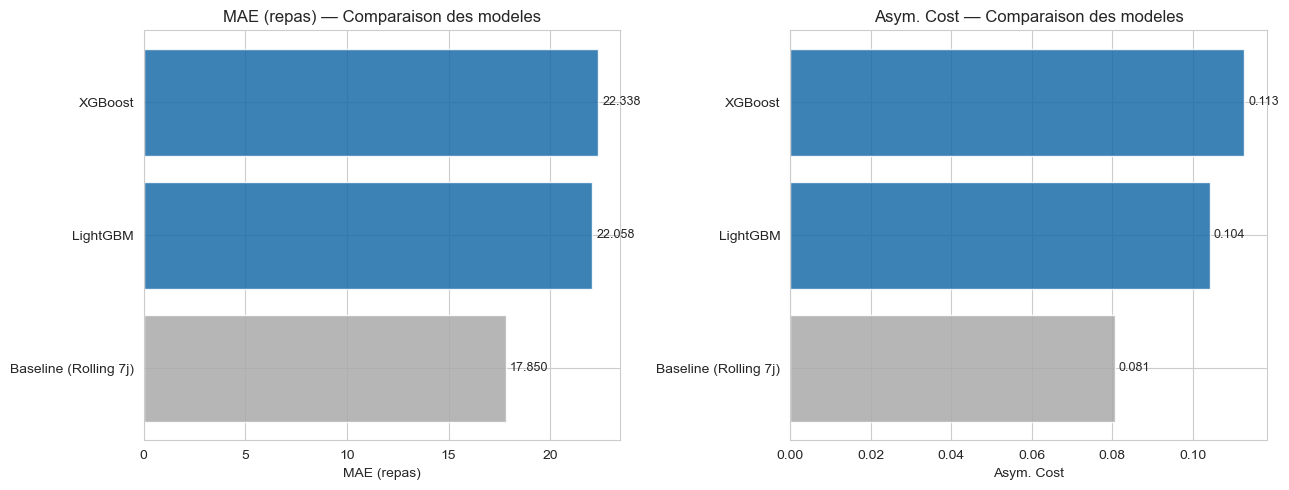

In [12]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics = ['MAE (repas)', 'Asym. Cost']
for ax, metric in zip(axes, metrics):
    vals  = comparison[metric].dropna()
    colors = ['#aaaaaa'] + ['#1b6ca8'] * (len(vals) - 1)
    bars = ax.barh(vals.index, vals.values, color=colors, alpha=0.85)
    ax.set_title(f'{metric} — Comparaison des modeles')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Tuning Optuna — Meilleur Modèle

Optimisation bayésienne sur 60 essais. Objectif : minimiser le coût asymétrique
moyen sur TimeSeriesSplit (5 folds).

> Ce bloc peut prendre **5–10 minutes** selon votre machine. Réduire `N_TRIALS` si besoin.

In [13]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("Optuna non disponible — tuning ignore.")

N_TRIALS = 60

def objective_lgbm(trial):
    params = dict(
        objective        = 'quantile',
        alpha            = trial.suggest_float('alpha', 0.65, 0.80),
        n_estimators     = trial.suggest_int('n_estimators', 200, 800),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 15, 63),
        min_child_samples= trial.suggest_int('min_child_samples', 5, 25),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        subsample_freq   = 1,
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-3, 2.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        random_state     = 42,
        verbosity        = -1,
    )
    tscv   = TimeSeriesSplit(n_splits=N_CV)
    costs  = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = LGBMRegressor(**params)
        m.fit(X_train.iloc[tr_idx], y_ratio.iloc[tr_idx])
        preds = m.predict(X_train.iloc[val_idx])
        y_cnt = np.round(y_ratio.iloc[val_idx].values * office_arr[val_idx]).astype(int)
        p_cnt = ratio_to_count(preds, office_arr[val_idx])
        costs.append(asymmetric_cost(y_cnt, p_cnt))
    return float(np.mean(costs))

def objective_catboost(trial):
    alpha = trial.suggest_float('alpha', 0.65, 0.80)
    params = dict(
        loss_function   = f'Quantile:alpha={alpha:.3f}',
        iterations      = trial.suggest_int('iterations', 200, 800),
        learning_rate   = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        depth           = trial.suggest_int('depth', 4, 8),
        l2_leaf_reg     = trial.suggest_float('l2_leaf_reg', 0.5, 10.0, log=True),
        random_seed     = 42,
        verbose         = 0,
    )
    tscv  = TimeSeriesSplit(n_splits=N_CV)
    costs = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = CatBoostRegressor(**params, cat_features=cat_feature_names)
        m.fit(X_train.iloc[tr_idx], y_ratio.iloc[tr_idx])
        preds = m.predict(X_train.iloc[val_idx])
        y_cnt = np.round(y_ratio.iloc[val_idx].values * office_arr[val_idx]).astype(int)
        p_cnt = ratio_to_count(preds, office_arr[val_idx])
        costs.append(asymmetric_cost(y_cnt, p_cnt))
    return float(np.mean(costs))

if HAS_OPTUNA and HAS_LGBM:
    objective_fn_map = {
        'LightGBM' : (objective_lgbm,  HAS_LGBM),
        'CatBoost' : (objective_catboost, HAS_CB),
    }
    best_obj_fn = objective_fn_map.get(best_model_name, (objective_lgbm, HAS_LGBM))

    if best_obj_fn[1]:
        study = optuna.create_study(direction='minimize')
        study.optimize(best_obj_fn[0], n_trials=N_TRIALS, show_progress_bar=True)

        print(f"\nMeilleurs hyperparametres ({best_model_name}) :")
        for k, v in study.best_params.items():
            print(f"  {k:25s}: {v}")
        print(f"Meilleur Asym. Cost CV : {study.best_value:.5f}")
    else:
        print(f"{best_model_name} non disponible pour le tuning.")
else:
    print("Optuna ou LightGBM manquant — on utilise les parametres par defaut.")
    study = None

Optuna non disponible — tuning ignore.
Optuna ou LightGBM manquant — on utilise les parametres par defaut.


In [14]:
# Historique d'optimisation
if HAS_OPTUNA and study is not None:
    trials_df = study.trials_dataframe()
    fig, ax   = plt.subplots(figsize=(10, 4))
    ax.plot(trials_df.index, trials_df['value'], '.', alpha=0.5, ms=4, color='#1b6ca8')
    ax.plot(trials_df.index,
            trials_df['value'].cummin(), '-', lw=2, color='#d9534f', label='Meilleur cumul')
    ax.set_title(f'Optuna — Historique des {N_TRIALS} essais ({best_model_name})')
    ax.set_xlabel('Essai')
    ax.set_ylabel('Asym. Cost (CV)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Ensemble Pondéré

On entraîne chaque modèle sur le **jeu d'entraînement complet** avec ses meilleurs
hyperparamètres, puis on combine les prédictions par pondération inverse du coût asymétrique CV.

**Poids :** $w_i = \frac{1 / \text{cost}_i}{\sum_j 1 / \text{cost}_j}$

Le modèle avec le meilleur coût CV reçoit le poids le plus fort.

In [16]:
# ── Construire les hyperparamètres finaux pour chaque modèle ────────────
final_models  = {}
final_weights = {}
cv_costs      = {}

# LightGBM
if HAS_LGBM:
    lgbm_best_params = {**LGBM_PARAMS}
    if HAS_OPTUNA and study is not None and best_model_name == 'LightGBM':
        lgbm_best_params.update(study.best_params)
    lgbm_final = LGBMRegressor(**lgbm_best_params)
    lgbm_final.fit(X_train, y_ratio)
    final_models['LightGBM'] = lgbm_final
    cv_costs['LightGBM'] = float(lgbm_cv.mean()['Asym. Cost'])



# XGBoost
if HAS_XGB:
    xgb_final = XGBRegressor(**XGB_PARAMS)
    xgb_final.fit(X_train, y_ratio)
    final_models['XGBoost'] = xgb_final
    cv_costs['XGBoost'] = float(xgb_cv.mean()['Asym. Cost'])

# ── Poids inversement proportionnels au coût ────────────────────────────
inv  = {k: 1.0 / max(v, 1e-9) for k, v in cv_costs.items()}
total = sum(inv.values())
final_weights = {k: v / total for k, v in inv.items()}

print("Modeles de l'ensemble et leurs poids :")
for k, w in sorted(final_weights.items(), key=lambda x: -x[1]):
    print(f"  {k:12s}: poids={w:.3f}  |  CV Asym. Cost={cv_costs[k]:.5f}")

Modeles de l'ensemble et leurs poids :
  LightGBM    : poids=0.520  |  CV Asym. Cost=0.10415
  XGBoost     : poids=0.480  |  CV Asym. Cost=0.11271


In [17]:
# ── Prédictions ensemble sur le train (évaluation en-sample) ─────────────
ensemble_ratio_train = np.zeros(len(X_train))
for name, model in final_models.items():
    ensemble_ratio_train += final_weights[name] * model.predict(X_train)

ensemble_scores = evaluate(y_ratio, ensemble_ratio_train, office_arr)
print("\n=== Scores Ensemble (train complet, in-sample) ===")
for k, v in ensemble_scores.items():
    print(f"  {k:20s}: {v}")

print("\nNote : les scores in-sample sont optimistes — se referer aux CV scores pour l'estimation reelle.")


=== Scores Ensemble (train complet, in-sample) ===
  MAE (repas)         : 4.78
  RMSE (repas)        : 9.15
  Asym. Cost          : 0.01906
  MAE (ratio)         : 0.00907

Note : les scores in-sample sont optimistes — se referer aux CV scores pour l'estimation reelle.


## 10. Importance des Features

Importance basée sur le gain (LightGBM `feature_importances_` de type `gain`).
Les 25 features les plus contributives sont affichées.

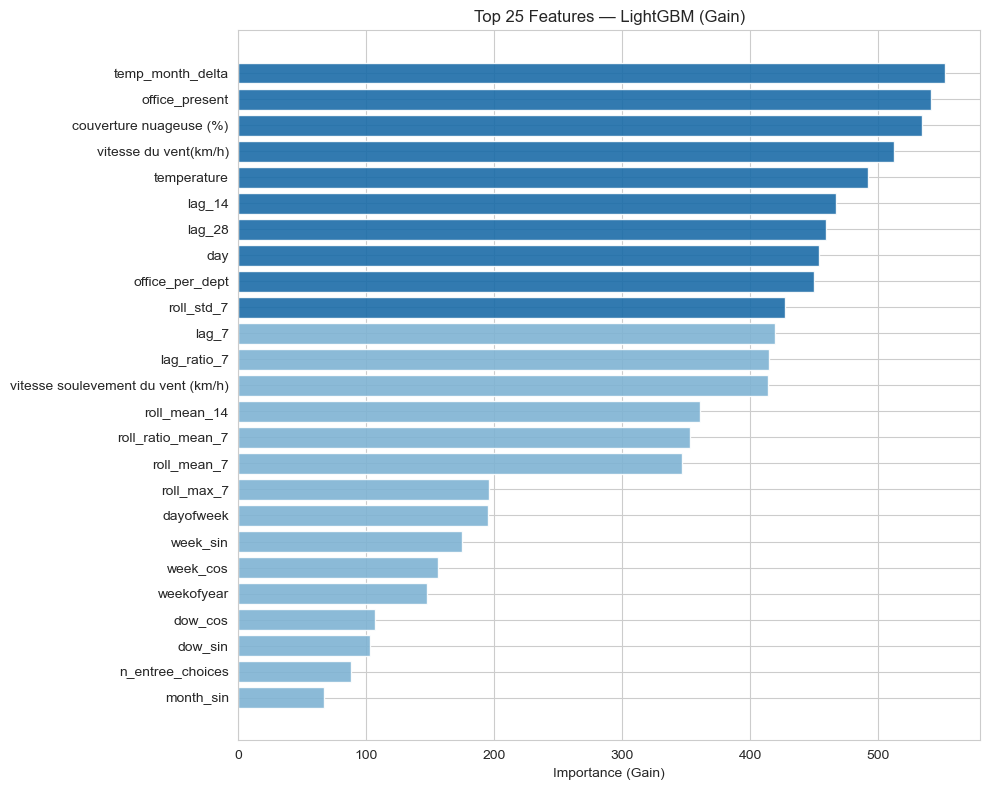


Top 15 features :
temp_month_delta                      552
office_present                        541
couverture nuageuse (%)               534
vitesse du vent(km/h)                 512
temperature                           492
lag_14                                467
lag_28                                459
day                                   454
office_per_dept                       450
roll_std_7                            427
lag_7                                 419
lag_ratio_7                           415
vitesse soulevement du vent (km/h)    414
roll_mean_14                          361
roll_ratio_mean_7                     353


In [18]:
if HAS_LGBM:
    importances = pd.Series(
        lgbm_final.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    top_n = 25
    top_feats = importances.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#1b6ca8' if i < 10 else '#7fb3d3' for i in range(top_n)]
    ax.barh(top_feats.index[::-1], top_feats.values[::-1], color=colors[::-1], alpha=0.9)
    ax.set_title(f'Top {top_n} Features — LightGBM (Gain)')
    ax.set_xlabel('Importance (Gain)')
    plt.tight_layout()
    plt.show()

    print("\nTop 15 features :")
    print(importances.head(15).round(1).to_string())

## 11. Prédictions Finales & Génération de la Soumission

Prédictions sur `X_test` → ratio prédit × `office_present_test` → `employees_count` entier.

In [19]:
# ── Prédictions test ─────────────────────────────────────────────────────
ensemble_ratio_test = np.zeros(len(X_test))
for name, model in final_models.items():
    ensemble_ratio_test += final_weights[name] * model.predict(X_test)

# Clip conservateur : 20% min, 95% max du ratio
ratio_lo = float(y_ratio.quantile(0.01))
ratio_hi = float(y_ratio.quantile(0.99))
ensemble_ratio_test = np.clip(ensemble_ratio_test,
                               max(0.20, ratio_lo - 0.03),
                               min(0.95, ratio_hi + 0.03))

pred_counts = ratio_to_count(ensemble_ratio_test, office_test)

print("Distribution des prédictions de repas (test 2024) :")
pred_series = pd.Series(pred_counts)
print(pred_series.describe().round(1))

Distribution des prédictions de repas (test 2024) :
count    229.0
mean     320.8
std       29.7
min      175.0
25%      309.0
50%      327.0
75%      339.0
max      380.0
dtype: float64


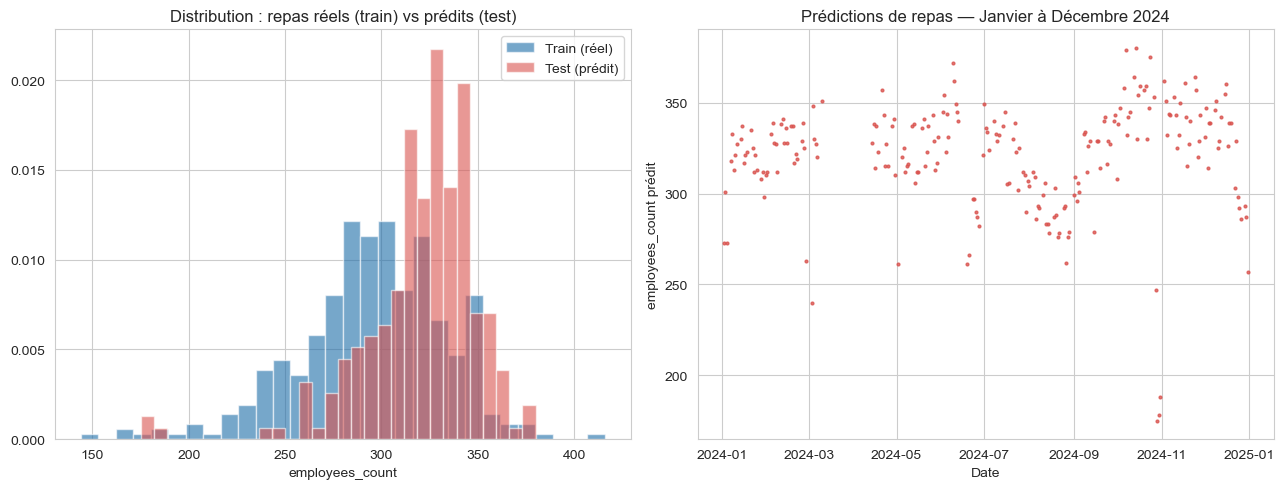

In [20]:
# ── Visualisation : distribution train vs test ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution
axes[0].hist(train['employees_count'], bins=30, alpha=0.6,
             label='Train (réel)', color='#1b6ca8', density=True)
axes[0].hist(pred_counts, bins=30, alpha=0.6,
             label='Test (prédit)', color='#d9534f', density=True)
axes[0].set_title('Distribution : repas réels (train) vs prédits (test)')
axes[0].set_xlabel('employees_count')
axes[0].legend()

# Série temporelle test
axes[1].plot(test['Date'], pred_counts, '.', ms=4, color='#d9534f', alpha=0.8)
axes[1].set_title('Prédictions de repas — Janvier à Décembre 2024')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('employees_count prédit')
axes[1].yaxis.set_major_locator(mticker.MultipleLocator(50))
plt.tight_layout()
plt.show()

In [21]:
# ── Génération du fichier de soumission ─────────────────────────────────
submission = pd.DataFrame({
    'Date'            : test['Date'].dt.strftime('%Y-%m-%d'),
    'employees_count' : pred_counts,
})

sub_path = OUT_DIR / 'submission.csv'
submission.to_csv(sub_path, index=False)

print(f"Soumission sauvegardee : {sub_path}")
print(f"Lignes : {len(submission)}")
print()
print(submission.head(10).to_string(index=False))

Soumission sauvegardee : d:\BNP_RIE_Stage\rie-project-skeleton\rie-project\data\processed\submission.csv
Lignes : 229

      Date  employees_count
2024-01-02              273
2024-01-03              301
2024-01-04              273
2024-01-07              318
2024-01-08              333
2024-01-09              313
2024-01-10              321
2024-01-11              327
2024-01-14              330
2024-01-15              337


In [22]:
# ── Sanity check final ────────────────────────────────────────────────────
assert len(submission) == len(test), "Nombre de lignes incorrect !"
assert submission['employees_count'].min() >= 0, "Valeurs negatives detectees !"
assert submission['employees_count'].isna().sum() == 0, "NaN dans la soumission !"

# Verifier que la distribution est raisonnable
ratio_check = (
    submission.merge(test[['Date', 'office_present']],
                     left_on='Date', right_on=test['Date'].dt.strftime('%Y-%m-%d'))
)
implied_ratio = ratio_check['employees_count'] / ratio_check['office_present']
print(f"Ratio implicite (min/mean/max) : "
      f"{implied_ratio.min():.3f} / {implied_ratio.mean():.3f} / {implied_ratio.max():.3f}")
print(f"Ratio entrainement (min/mean/max) : "
      f"{y_ratio.min():.3f} / {y_ratio.mean():.3f} / {y_ratio.max():.3f}")
print()
print("[OK] Soumission validee — aucun probleme detecte.")

Ratio implicite (min/mean/max) : 0.525 / 0.573 / 0.611
Ratio entrainement (min/mean/max) : 0.309 / 0.553 / 0.739

[OK] Soumission validee — aucun probleme detecte.
